# HTTP2vec - Reproduction and Critical Study

Reproduction of **"HTTP2vec: Embedding of HTTP Requests for Detection of Anomalous
Traffic"** (Gniewkowski et al., 2021, arXiv:2108.01763) on the **CSIC 2010** dataset.

**Problem.** Most web attacks (SQL injection, XSS, CRLF, ...) travel over HTTP.
We want to flag anomalous HTTP requests. **Idea of the paper.** Treat an HTTP
request as text, learn a language model (RoBERTa) on *normal* traffic only, use
its hidden states to embed each request, then classify the embeddings.

This notebook walks through: data loading and inspection, EDA, the embedding
"feature engineering", model training (supervised classifiers **and** an
unsupervised Isolation Forest), evaluation, and error analysis. All logic lives
in the `http2vec` package; cells just orchestrate it.


## Colab bootstrap

When this notebook is opened directly from GitHub in Google Colab, only the
notebook file is present - the `http2vec` package and the CSIC2010 dataset are
not. This cell clones the repo, installs the package, and downloads the data. It
is a no-op when run locally (where the repo is already present), so the same
notebook works in both places.

In [1]:
import sys, os, pathlib

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.chdir("/content")
    !rm -rf /content/cyberAno /cyberAno
    !git clone https://github.com/nirmanor1/cyberAno.git /content/cyberAno
    os.chdir("/content/cyberAno")
    !pip install -q -e . sentencepiece
    if not pathlib.Path("/content/cyberAno/data/raw/normalTrafficTraining.txt").exists():
        !python scripts/download_data.py --dest data/raw
    print("cwd is now:", os.getcwd())
else:
    print("Local run: skipping Colab bootstrap.")

Cloning into '/content/cyberAno'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 258 (delta 4), reused 4 (delta 4), pack-reused 252 (from 1)
Receiving objects: 100% (258/258), 19.53 MiB | 17.36 MiB/s, done.
Resolving deltas: 100% (92/92), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for http2vec (pyproject.toml) ... done
cwd is now: /content/cyberAno


## 0. Setup

In [ ]:
import os, sys, pathlib
root = pathlib.Path.cwd()
for _ in range(6):
    if (root / "pyproject.toml").exists() or (root / "data" / "raw").is_dir():
        break
    root = root.parent
os.chdir(root)
try:
    import http2vec  # noqa: F401
except ModuleNotFoundError:
    if (root / "src" / "http2vec").is_dir():
        sys.path.insert(0, str(root / "src"))
    import http2vec  # noqa: F401

%matplotlib inline
import numpy as np
import pandas as pd

from http2vec.config import ExperimentConfig
from http2vec.utils import configure_logging, set_seed, resolve_device
from http2vec.visualization.plots import save_figure

configure_logging()
print("http2vec", http2vec.__version__, "| device:", resolve_device("auto"))


REPORTS_DIR = pathlib.Path("reports")
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def show(fig, name):
    # Save the figure into reports/figures and return it for inline display.
    save_figure(fig, name, FIG_DIR)
    return fig

http2vec 0.1.0 | device: cuda


### Choose a configuration profile

The default here is the **`small`** profile: the full paper-size RoBERTa on a
seeded **40% subset** for **5 epochs** - a lighter stand-in for the full run.
Both profiles are heavy enough that a GPU (CUDA) is recommended.

- `small` - full paper-size model on a seeded 40% subset, 5 epochs (default here).
- `paper` - full dataset, paper-size RoBERTa, 10 epochs.


In [ ]:
PROFILE = "small"        # "small" (40% / 5ep, full model) | "paper" (full / 10ep)
EPOCHS_OVERRIDE = None    
SUBSET_FRACTION = 0.4  

RAW_DIR = pathlib.Path("data/raw")
REQUIRED = ["normalTrafficTraining.txt", "normalTrafficTest.txt", "anomalousTrafficTest.txt"]
missing = [name for name in REQUIRED if not (RAW_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "Missing CSIC2010 files in data/raw: " + ", ".join(missing)
        + ". Download them first: python scripts/download_data.py (see data/README.md)."
    )

kwargs = dict(raw_dir=str(RAW_DIR), device="auto", subset_fraction=SUBSET_FRACTION)
if EPOCHS_OVERRIDE is not None:
    kwargs["num_train_epochs"] = EPOCHS_OVERRIDE
config = getattr(ExperimentConfig, PROFILE)(**kwargs)
set_seed(config.seed)
config

ExperimentConfig(data=DataConfig(raw_dir=PosixPath('data/raw'), normal_train_file='normalTrafficTraining.txt', normal_test_file='normalTrafficTest.txt', anomalous_test_file='anomalousTrafficTest.txt', max_lm_train_samples=None, max_inference_per_class=None, subset_fraction=0.4, subset_seed=42, first_line_only=False, encode_crlf_literally=True), tokenizer=TokenizerConfig(vocab_size=30000, min_frequency=2, max_length=512), model=ModelConfig(hidden_size=768, num_hidden_layers=6, num_attention_heads=12, intermediate_size=3072, num_train_epochs=5, per_device_batch_size=32, learning_rate=5e-05, weight_decay=0.01, warmup_ratio=0.06, mlm_probability=0.15, eval_fraction=0.05), embedding=EmbeddingConfig(last_n_layers=4, token_pooling='mean', line_aggregation='mean', batch_size=32), classifier=ClassifierConfig(cv_folds=5, test_size=0.3, random_state=42, scale_features=True, lr_max_iter=2000, rf_n_estimators=100, svc_c=1.0, svc_max_iter=5000, gb_n_estimators=100, knn_n_neighbors=15, iforest_n_esti

## 1. Data loading and inspection

The loader returns three views (matching the paper): `lm_train` (normal-only, used
to train the language model), `inference` (labelled normal + anomalous, used for
classification) and `tokenizer_corpus` (all traffic, used to train the tokenizer).

In [4]:
from http2vec.data.loaders import Csic2010Loader

bundle = Csic2010Loader(config.data).load()
print(f"lm_train (normal only):      {len(bundle.lm_train)}")
print(f"inference (normal+anomaly):  {len(bundle.inference)}")
print(f"tokenizer_corpus (all):      {len(bundle.tokenizer_corpus)}")

# Peek at one normal and one anomalous request (first line only, as text).
inf = bundle.inference.requests
example_normal = next(r for r in inf if int(r.label) == 0)
example_anomaly = next(r for r in inf if int(r.label) == 1)
print("\nNormal  :", example_normal.request_line[:160])
print("Anomaly :", example_anomaly.request_line[:160])

[INFO] http2vec: Loaded CSIC2010: lm_train=14400, inference=24426 (normal=14400, anomaly=10026), tokenizer_corpus=38826


lm_train (normal only):      14400
inference (normal+anomaly):  24426
tokenizer_corpus (all):      38826

Normal  : GET http://localhost:8080/tienda1/publico/anadir.jsp?id=1&nombre=Jam%F3n+Ib%E9rico&precio=39&cantidad=41&B1=A%F1adir+al+carrito HTTP/1.1
Anomaly : POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1


We turn each request into a small table of **descriptive features** (length,
number of parameters, %-encoding ratio, entropy, attack-signature flags, ...).
These are *not* the model features - they exist so we can do classical EDA.

In [5]:
from http2vec.data.features import feature_frame

inference_df = feature_frame(bundle.inference)
print("shape:", inference_df.shape)
print("\ndtypes:\n", inference_df.dtypes)
inference_df.head()

shape: (24426, 16)

dtypes:
 method                   object
target_length             int64
body_length               int64
n_headers                 int64
n_query_params            int64
path_depth                int64
has_body                  int64
pct_encoding_count        int64
pct_encoding_ratio      float64
digit_ratio             float64
upper_ratio             float64
non_alnum_ratio         float64
shannon_entropy         float64
contains_sql_keyword      int64
contains_script_tag       int64
label                     int64
dtype: object


,method,target_length,body_length,n_headers,n_query_params,path_depth,has_body,pct_encoding_count,pct_encoding_ratio,digit_ratio,upper_ratio,non_alnum_ratio,shannon_entropy,contains_sql_keyword,contains_script_tag,label
0,GET,123,0,10,5,3,0,3,0.02439,0.113821,0.056911,0.195122,4.869027,0,0,0
1,POST,48,74,12,0,3,1,3,0.02459,0.114754,0.057377,0.188525,4.840254,0,0,0
2,GET,113,0,10,5,3,0,0,0.00000,0.053097,0.017699,0.159292,4.628747,0,0,0
3,GET,62,0,10,1,3,0,0,0.00000,0.096774,0.000000,0.161290,4.370116,0,0,0
4,POST,57,4,12,0,3,1,0,0.00000,0.098361,0.000000,0.147541,4.320688,0,0,0


In [6]:
# Data-quality checks: missing values, duplicate rows, constant (single-value)
# columns, and duplicate (exactly redundant) feature columns.
print("Missing values per column:\n", inference_df.isna().sum())
print("\nFully duplicated rows:", int(inference_df.duplicated().sum()))
constant_cols = [c for c in inference_df.columns if inference_df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)
# Transpose so each former column becomes a row; duplicated() then flags columns
# whose values are identical to an earlier one (a vectorised redundancy check).
duplicate_feature_cols = inference_df.columns[inference_df.T.duplicated()].tolist()
print("Duplicate feature columns:", duplicate_feature_cols)
inference_df.describe(include="all").T

Missing values per column:
 method                  0
target_length           0
body_length             0
n_headers               0
n_query_params          0
path_depth              0
has_body                0
pct_encoding_count      0
pct_encoding_ratio      0
digit_ratio             0
upper_ratio             0
non_alnum_ratio         0
shannon_entropy         0
contains_sql_keyword    0
contains_script_tag     0
label                   0
dtype: int64

Fully duplicated rows: 15678
Constant columns: []
Duplicate feature columns: []


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
method,24426,3,GET,17159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_length,24426.0,NaN,NaN,NaN,81.4817,75.737216,22.0,48.0,50.0,68.0,886.0
body_length,24426.0,NaN,NaN,NaN,32.436625,76.086395,0.0,0.0,0.0,18.0,835.0
n_headers,24426.0,NaN,NaN,NaN,10.595022,0.914345,10.0,10.0,10.0,12.0,12.0
n_query_params,24426.0,NaN,NaN,NaN,1.613322,3.603426,0.0,0.0,0.0,1.0,13.0
path_depth,24426.0,NaN,NaN,NaN,3.006264,0.476856,0.0,3.0,3.0,3.0,6.0
has_body,24426.0,NaN,NaN,NaN,0.297511,0.457173,0.0,0.0,0.0,1.0,1.0
pct_encoding_count,24426.0,NaN,NaN,NaN,1.865553,6.349044,0.0,0.0,0.0,2.0,114.0
pct_encoding_ratio,24426.0,NaN,NaN,NaN,0.008625,0.018992,0.0,0.0,0.0,0.010453,0.177236
digit_ratio,24426.0,NaN,NaN,NaN,0.121383,0.059961,0.048193,0.09322,0.104348,0.136364,0.64878


**Columns and index - does this make sense?** The columns are descriptive,
model-agnostic attributes (lengths, counts, ratios, entropy, attack-signature
flags) plus the `label`; the names are self-explanatory and appropriate for EDA.
The frame uses a default positional integer index (one row per request): CSIC has
no natural key (no request id, no timestamp), so a positional index is the
sensible choice and conveniently aligns row *i* with
`bundle.inference.requests[i]` for error analysis later. The checks above confirm
no missing values and no exactly-duplicated feature columns; correlation-based
redundancy is examined in the EDA section.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class balance (prevalence)

In the CSIC inference set the classes are roughly 59% normal / 41% anomalous
(the `small` subset profile keeps a seeded fraction of each file, so this ratio is
preserved). Accuracy is therefore sensitive to the imbalance - prefer F1, MCC and
ROC-AUC.

In [7]:
counts = inference_df["label"].value_counts().rename({0: "normal", 1: "anomaly"})
shares = inference_df["label"].value_counts(normalize=True).rename({0: "normal", 1: "anomaly"})
pd.DataFrame({"count": counts, "share": shares.round(3)})

,count,share
label,,
normal,14400,0.59
anomaly,10026,0.41


### 2.2 Feature distributions by class

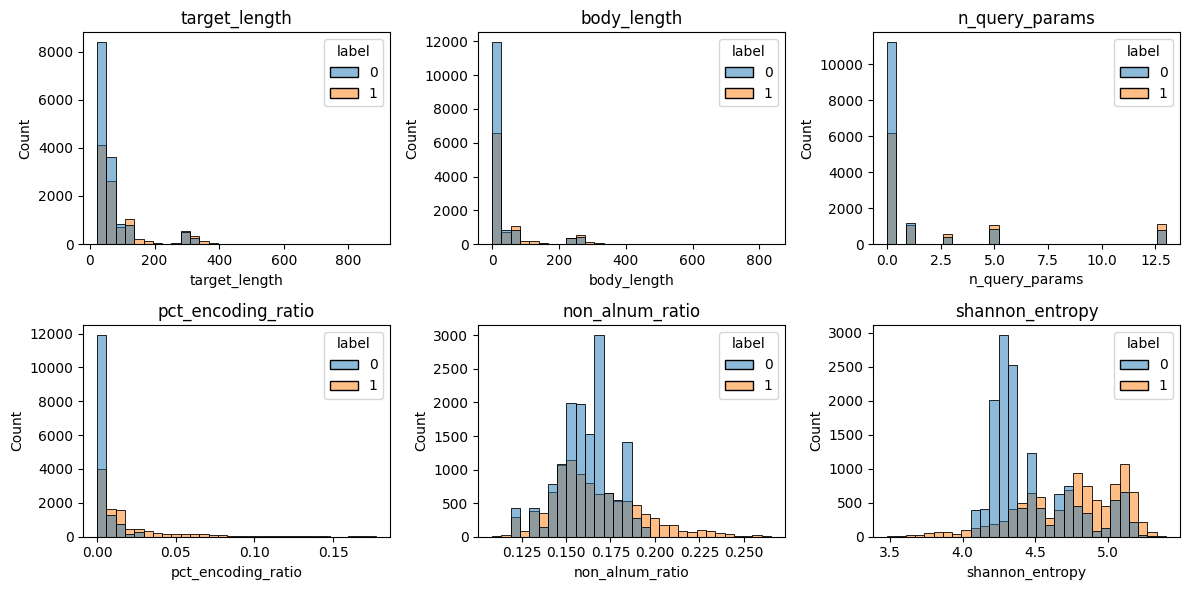

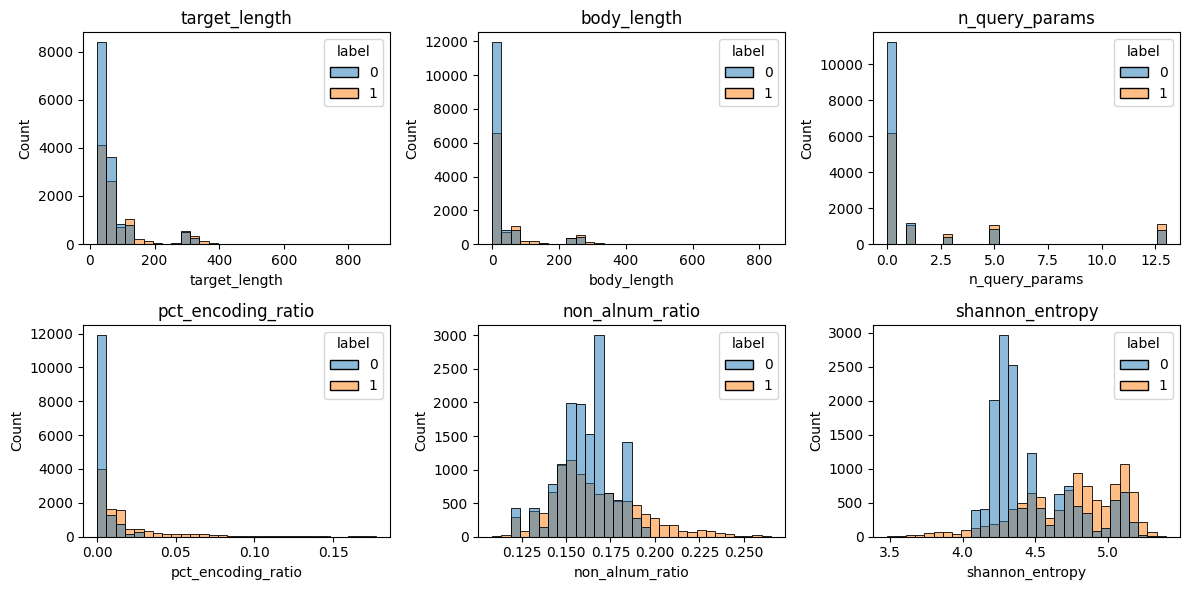

In [8]:
from http2vec.visualization.plots import plot_feature_distributions

dist_cols = ["target_length", "body_length", "n_query_params",
             "pct_encoding_ratio", "non_alnum_ratio", "shannon_entropy"]
fig = plot_feature_distributions(inference_df, dist_cols, hue="label")
show(fig, "2_2_feature_distributions")

### 2.3 Correlation analysis

We report **Spearman** correlation as the primary measure: the descriptive
features are skewed, non-normal and contain outliers (attack payloads can be very
long), and we mostly care about *monotonic* association rather than strictly
linear association. For reference:

- **Pearson** - linear association between continuous variables; sensitive to
  outliers and assumes roughly linear, normal-ish data.
- **Spearman** - rank-based; captures monotonic relationships and is robust to
  outliers and non-normality (our case).
- **Kendall** - also rank-based; preferred for small samples / many ties, with a
  more conservative interpretation.

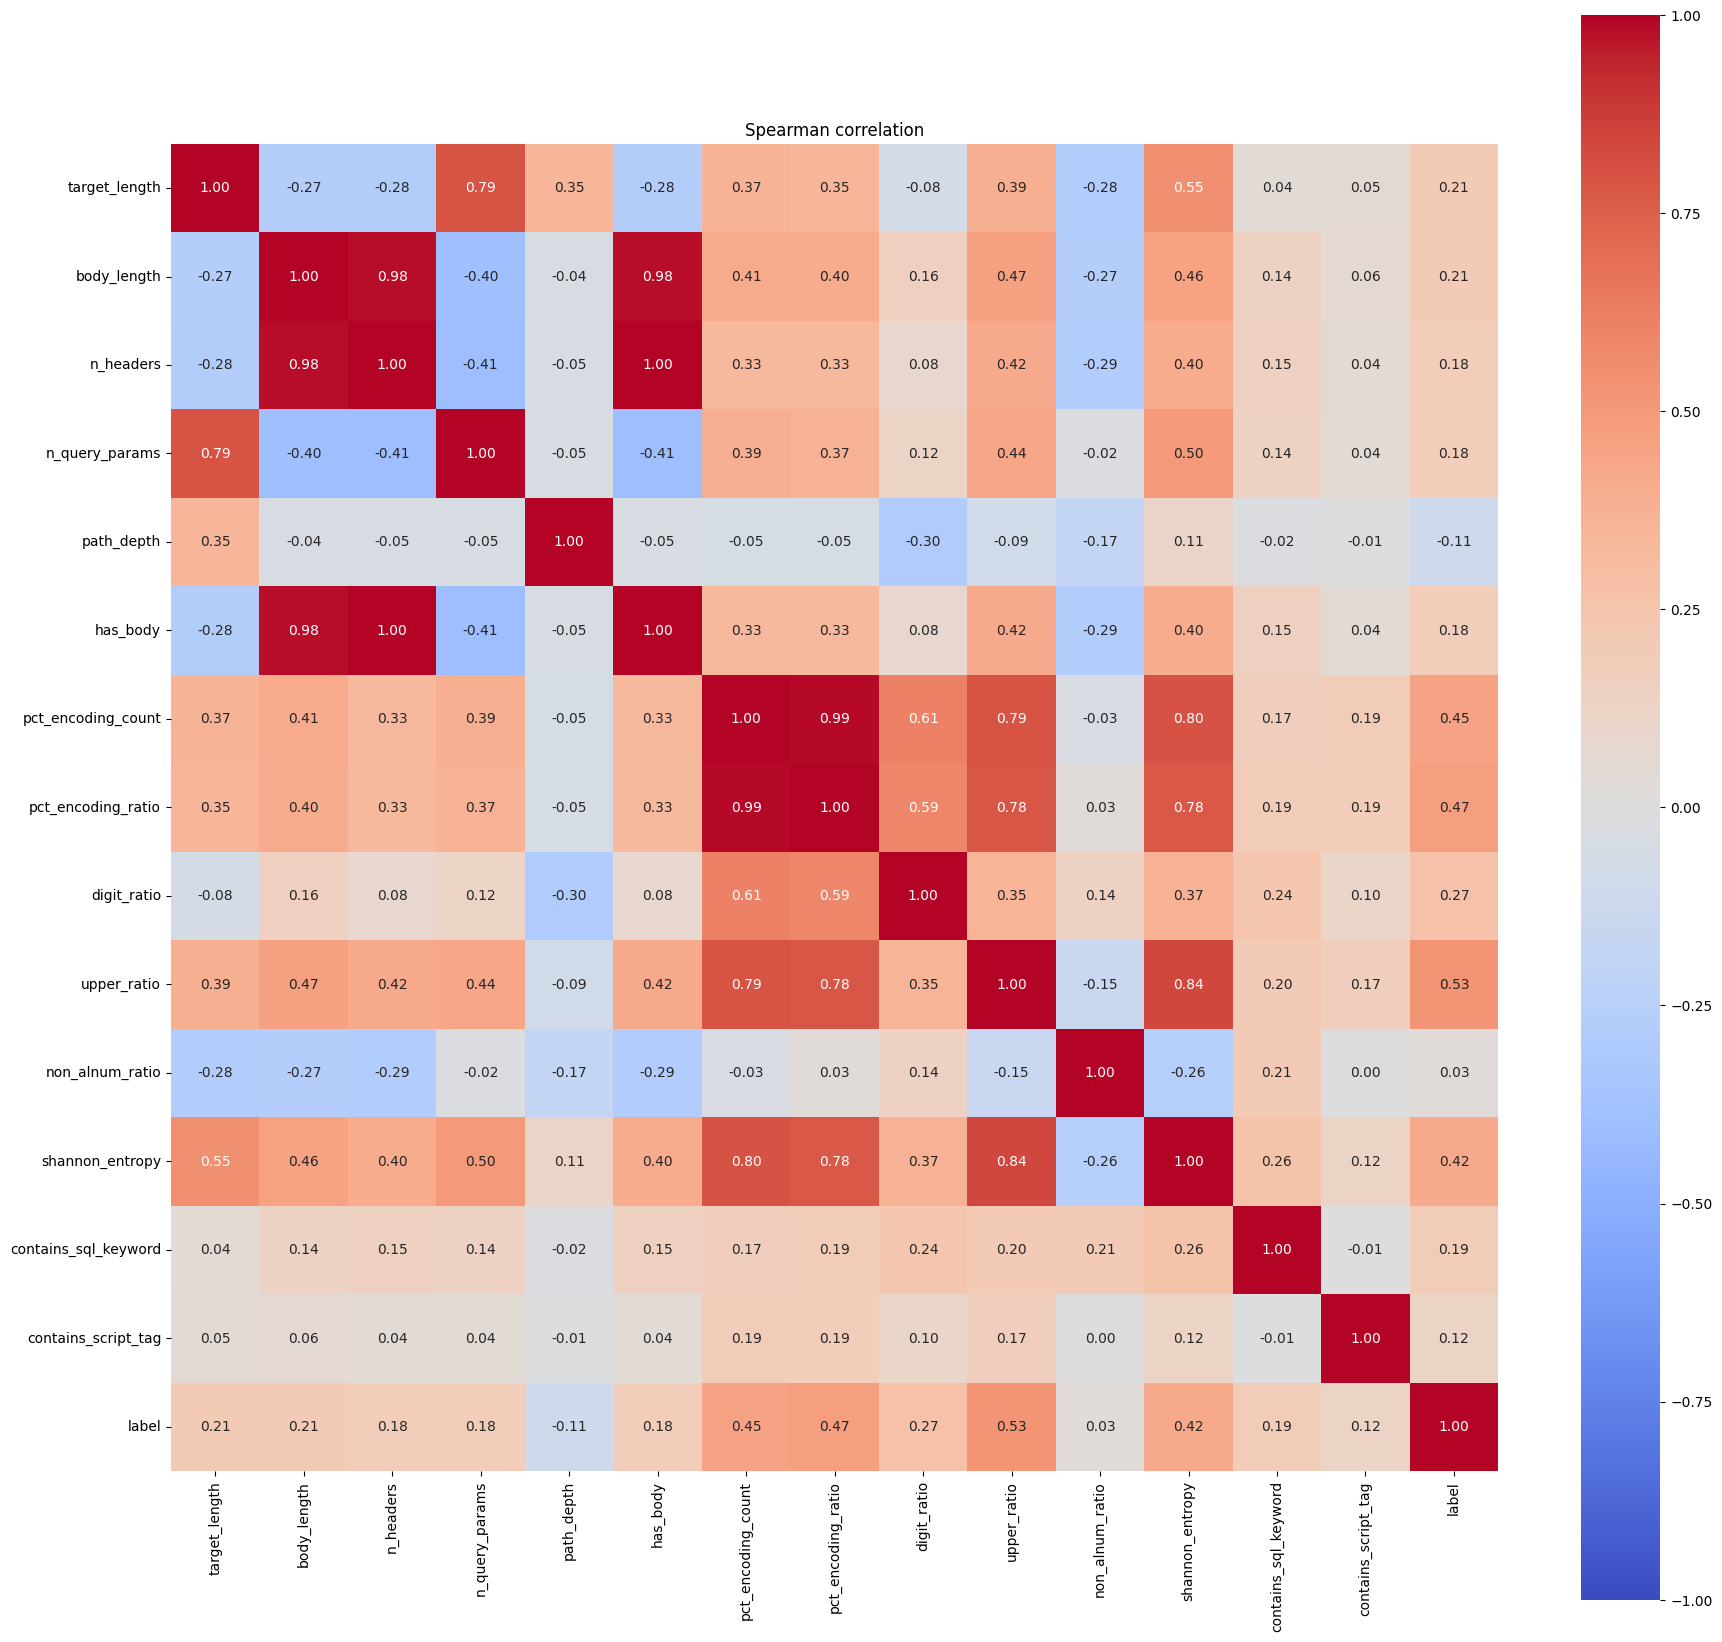

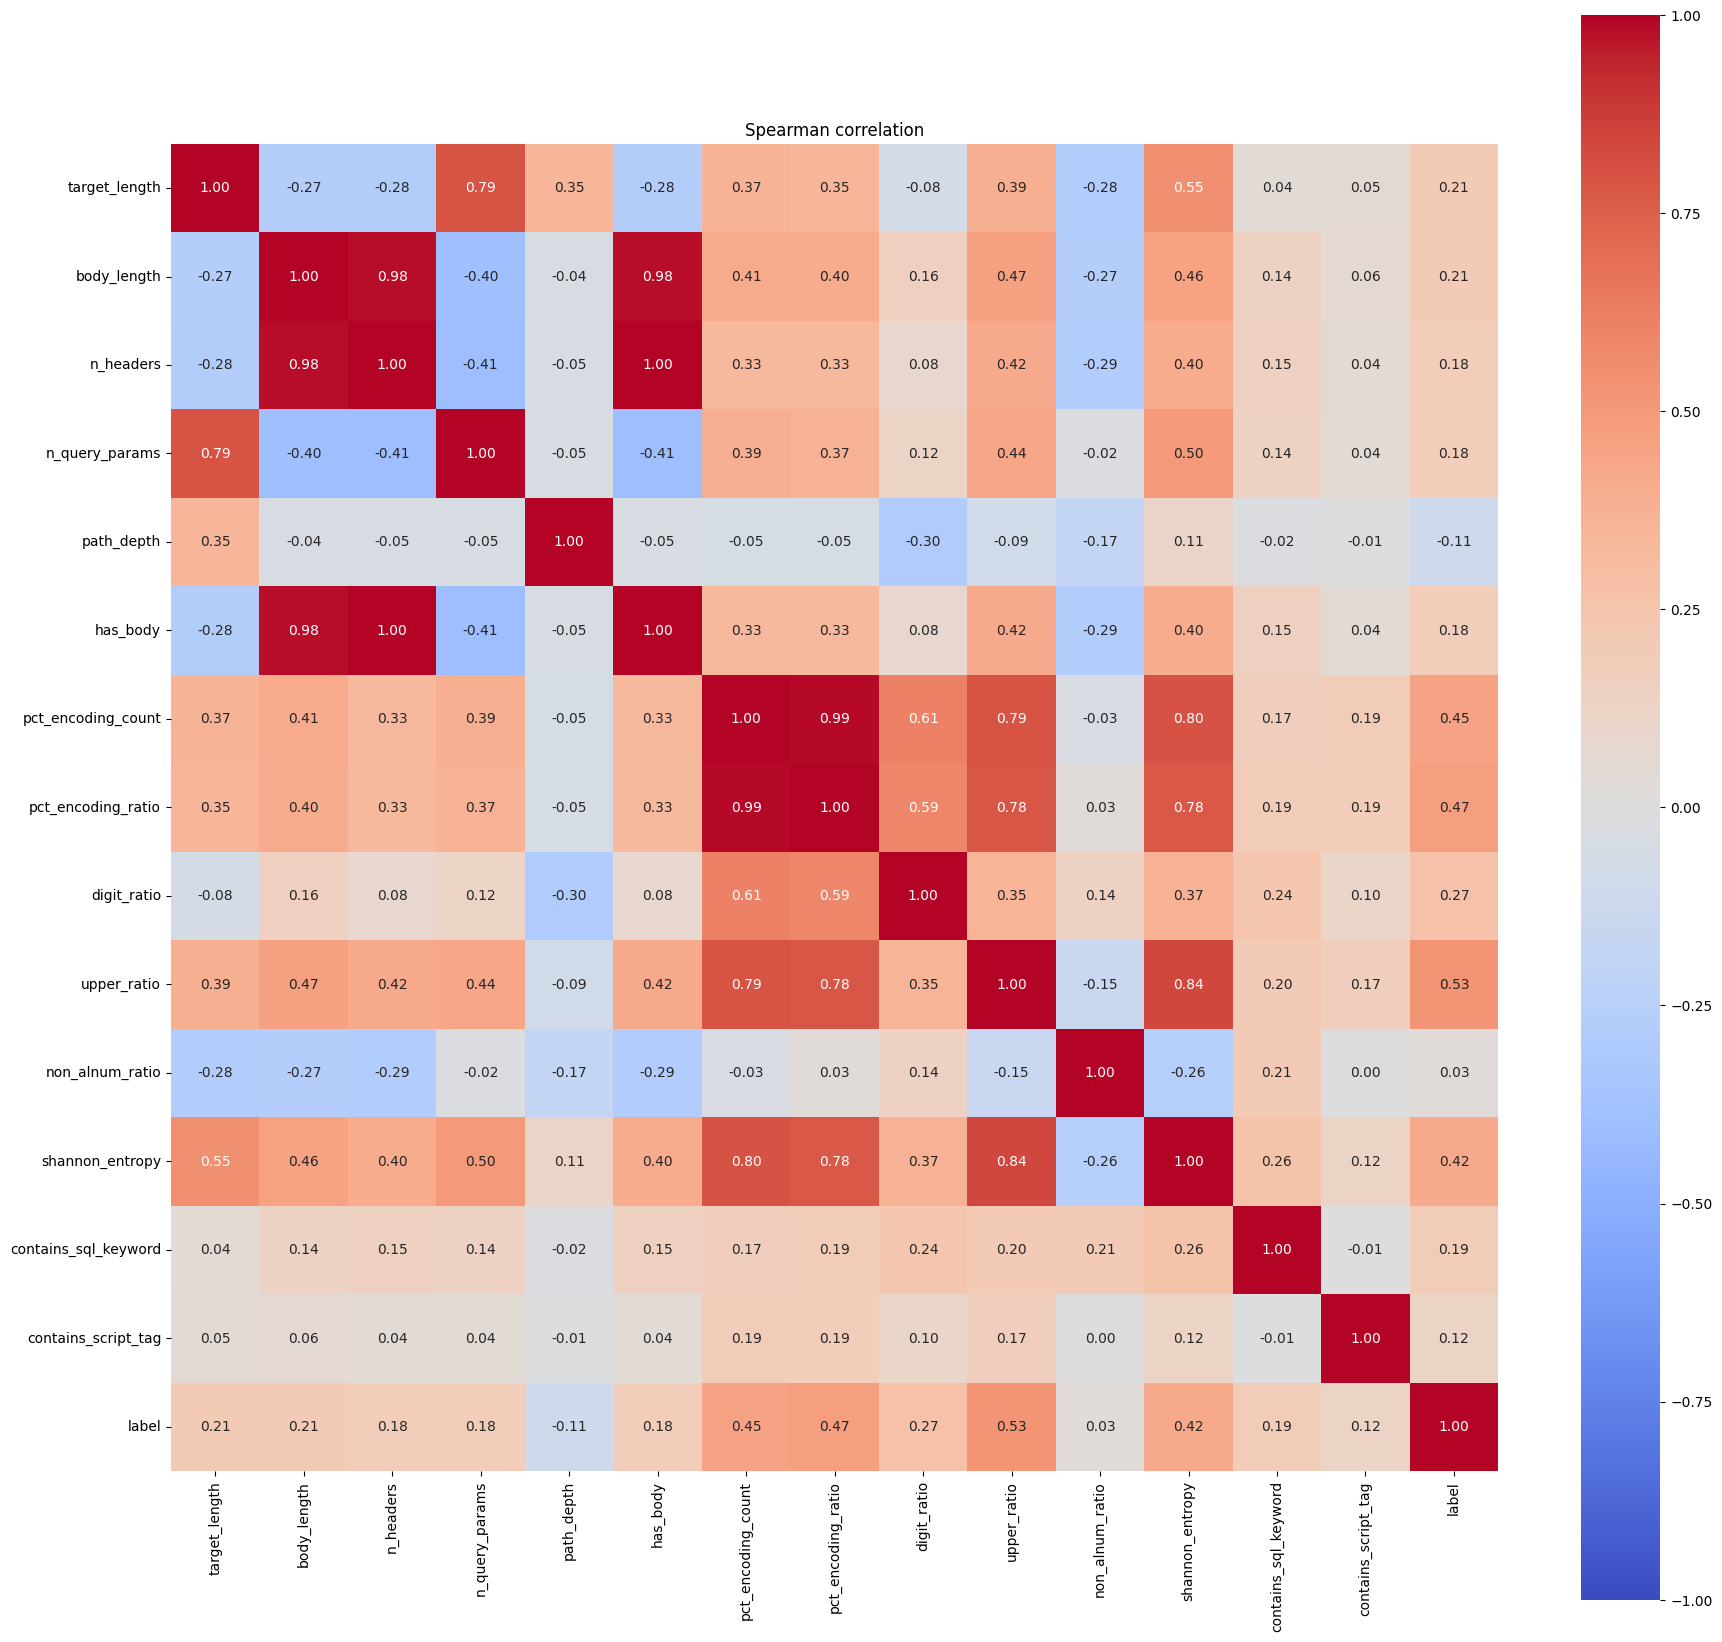

In [9]:
from http2vec.visualization.plots import plot_correlation_heatmap

fig = plot_correlation_heatmap(inference_df, method="spearman")
show(fig, "2_3_correlation_spearman")

In [10]:
# Cross-tabulate HTTP method against the label (group-by style view).
pd.crosstab(inference_df["method"], inference_df["label"].map({0: "normal", 1: "anomaly"}))

label,anomaly,normal
method,,
GET,6040,11119
POST,3818,3281
PUT,168,0


### 2.4 How duplicated is CSIC, really? Three levels of templating

CSIC 2010 is generated by exercising a single e-commerce application, so it is
heavily templated - but *where* the duplication lives matters. We measure it at
three levels, from strict to loose:

1. **Full raw text** - the exact request including headers/body. Volatile fields
   (cookies, lengths, payload values) make almost every request unique, so this
   is ~0% - there are essentially no byte-for-byte copies.
2. **Request first line** (method + URL) - the request's "identity" modulo those
   volatile fields. This is where the real repetition shows: a large fraction of
   requests reuse the same endpoint/template.
3. **Descriptive fingerprint** - the Section 1 feature row (lengths, ratios,
   flags); this reproduces the report's ~64% figure.

The gap between level 1 and levels 2-3 is the point: the effective diversity of
the data is far below the row count even though no two requests are identical.
This templating - not raw copies - is what inflates cross-validated / holdout
scores, quantified in Section 4.4.

In [11]:
from http2vec.data.duplicates import duplicate_report

# Strict -> loose duplication views of the same inference set.
raw_texts = bundle.inference.texts()
first_lines = [r.request_line for r in bundle.inference.requests]
raw_dup = duplicate_report(raw_texts)
line_dup = duplicate_report(first_lines)
fp_n_dup = int(inference_df.duplicated().sum())
fp_rate = float(inference_df.duplicated().mean())

duplicate_analysis = {
    "raw_text": raw_dup,
    "first_line": line_dup,
    "descriptive_fingerprint": {
        "n_total": len(inference_df),
        "n_duplicate": fp_n_dup,
        "duplicate_rate": fp_rate,
    },
}
print(f"Full raw text            : {raw_dup['duplicate_rate']:6.1%} duplicated  ({raw_dup['n_unique']} unique)")
print(f"Request first line (URL) : {line_dup['duplicate_rate']:6.1%} duplicated  ({line_dup['n_unique']} unique)")
print(f"Descriptive fingerprint  : {fp_rate:6.1%} duplicated  ({len(inference_df) - fp_n_dup} unique)")

Full raw text            :   0.0% duplicated  (24426 unique)
Request first line (URL) :  75.3% duplicated  (6040 unique)
Descriptive fingerprint  :  64.2% duplicated  (8748 unique)


### 2.5 Outliers and temporal note

`target_length` / `body_length` are heavy-tailed - long values are often attack
payloads, so "outliers" here are signal, not noise, and we keep them. The CSIC
dataset has **no timestamps**, so a temporal analysis is not applicable; this is a
limitation to note (concept drift cannot be studied with this data alone).

In [12]:
inference_df[["target_length", "body_length", "shannon_entropy"]].describe(
    percentiles=[0.5, 0.9, 0.99]
).T

,count,mean,std,min,50%,90%,99%,max
target_length,24426.0,81.481700,75.737216,22.000000,50.000000,131.000000,340.00000,886.00000
body_length,24426.0,32.436625,76.086395,0.000000,0.000000,83.000000,291.00000,835.00000
shannon_entropy,24426.0,4.577984,0.338996,3.481715,4.459294,5.095389,5.21867,5.39727


## 3. Feature engineering: the HTTP2vec representation

The real features are RoBERTa embeddings. We:

1. train a byte-level BPE tokenizer on **all** traffic,
2. train a RoBERTa masked-language-model on **normal traffic only**,
3. embed each request as the mean (over its lines) of the concatenated last
   hidden layers.

These steps reuse the pipeline's stage methods so the notebook and the
programmatic `Http2VecPipeline.run()` share exactly one implementation.

> This trains the RoBERTa on the selected profile's normal traffic and embeds its
> requests - heavy, so a GPU is recommended. The default `small` profile uses the
> full-size model on a 60% subset for 5 epochs; `paper` is the full run.

In [13]:
from http2vec.pipeline import Http2VecPipeline

pipeline = Http2VecPipeline(config, loader=Csic2010Loader(config.data))

tokenizer = pipeline.build_tokenizer(bundle)
model = pipeline.train_language_model(bundle, tokenizer)
embedder = pipeline.build_embedder(model, tokenizer)
print("tokenizer vocab:", tokenizer.vocab_size, "| embedding dim:", embedder.embedding_dim)

[INFO] http2vec: Trained BBPE tokenizer (vocab=30000) -> artifacts/tokenizer
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[INFO] http2vec: Training RoBERTa MLM on 13680 examples (720 held out for eval) for 5 epoch(s).


Epoch,Training Loss,Validation Loss
1,1.610624,1.591012
2,1.283918,1.133031
3,1.142680,0.962048
4,0.925384,0.919686
5,1.001362,0.916511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

tokenizer vocab: 30000 | embedding dim: 3072


### 3.1 Training progress (loss curve)

Because we train for only a few epochs, we capture the learning in detail: the
per-step **training loss** plus the **validation loss** evaluated once per epoch
on a seeded held-out slice of normal traffic (`ModelConfig.eval_fraction`). The
right-hand axis shows **perplexity** (`exp(loss)`). A loss that falls steadily
while the validation loss tracks it (rather than turning back up) indicates the
masked-language model is learning the structure of normal HTTP traffic without
obvious overfitting. The raw history is also saved to
`artifacts/roberta-mlm/training_log.json`.

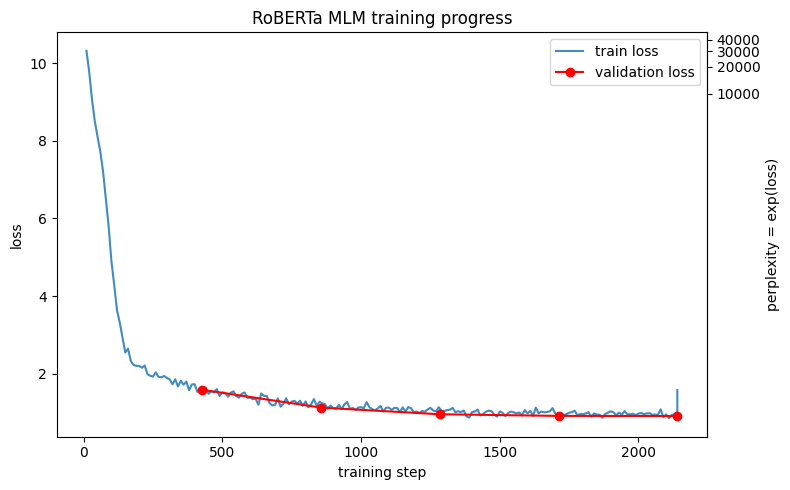

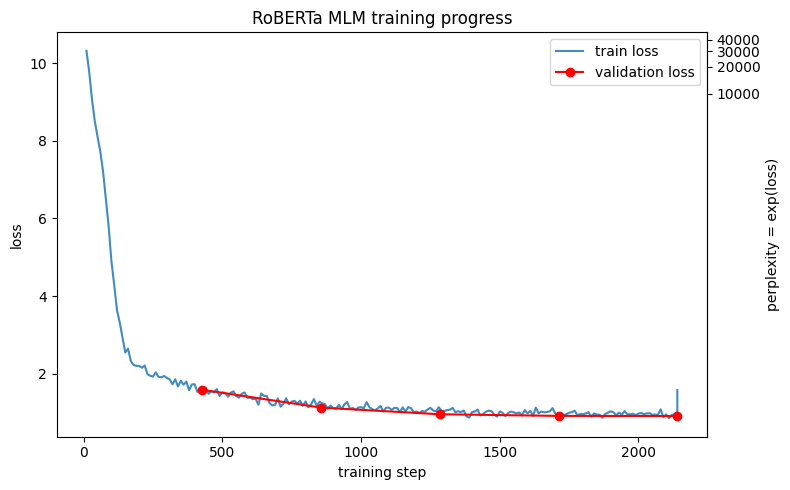

In [14]:
from http2vec.visualization.plots import plot_training_curve

fig = plot_training_curve(pipeline.training_history)
show(fig, "3_1_training_curve")

In [15]:
embeddings = pipeline.compute_embeddings(embedder, bundle)
X = embeddings.inference_x
y = embeddings.inference_y
print("inference embeddings:", X.shape, "| normal-train embeddings:", embeddings.normal_train_x.shape)

[INFO] http2vec: Embedding inference set (24426 requests).
[INFO] http2vec: Embedding normal-train set (14400 requests).


inference embeddings: (24426, 3072) | normal-train embeddings: (14400, 3072)


### 3.2 Visualising the embedding space (t-SNE)

If the representation is good, normal and anomalous requests should separate even
in 2-D. Scaling of embeddings for the classifiers is handled inside the
classifier wrappers (a `StandardScaler` for the linear models).

t-SNE on a random sample of 3000 of 24426 requests.


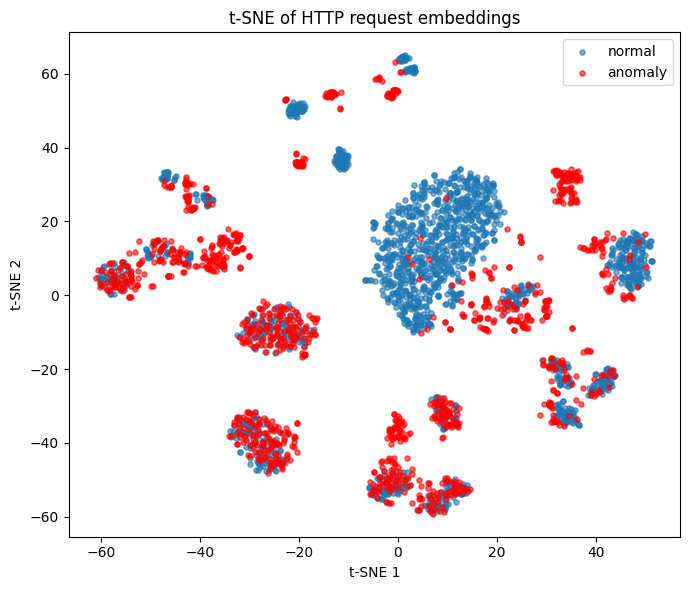

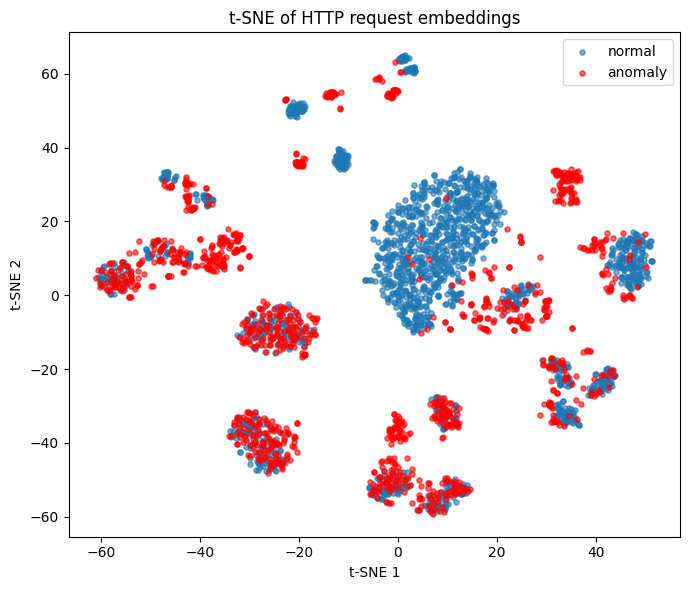

In [ ]:
from http2vec.visualization.plots import plot_tsne

rng = np.random.default_rng(config.seed)
max_points = 3000
if len(y) > max_points:
    sel = rng.choice(len(y), size=max_points, replace=False)
    tsne_x, tsne_y = X[sel], y[sel]
    print(f"t-SNE on a random sample of {max_points} of {len(y)} requests.")
else:
    tsne_x, tsne_y = X, y
fig = plot_tsne(tsne_x, tsne_y, seed=config.seed)
show(fig, "3_2_tsne_embeddings")

### 3.3 Feature engineering summary

Mapping our pipeline onto the standard feature-engineering checklist:

- **Encoding (categorical -> numeric).** Raw requests are text; the byte-level BPE
  tokenizer *is* the encoding step, turning bytes into token ids with no
  out-of-vocabulary problem. The descriptive `method` column is categorical and
  used only for EDA (the crosstab above); the model never one-hot encodes it
  because the model features are the dense embeddings.
- **Feature creation.** Two sets: human-readable descriptive features (for EDA)
  and the real model features - RoBERTa embeddings, the concatenation of the last
  4 hidden layers, mean-pooled over tokens and averaged over a request's lines
  (3072-dim for the full model).
- **Scaling.** Embeddings are standardized (`StandardScaler`) inside the linear
  classifiers, the anomaly detectors and the MLP head; tree ensembles skip it
  (scale-invariant).
- **Feature selection / dimensionality reduction.** Individual embedding
  dimensions are not human-interpretable, so we do not prune them by hand; instead
  the PCA curve below quantifies how few components already capture most variance
  (intrinsic dimensionality), and t-SNE gives a 2-D view. This is the paper's
  noted limitation (a ~3000-dim representation) made concrete.

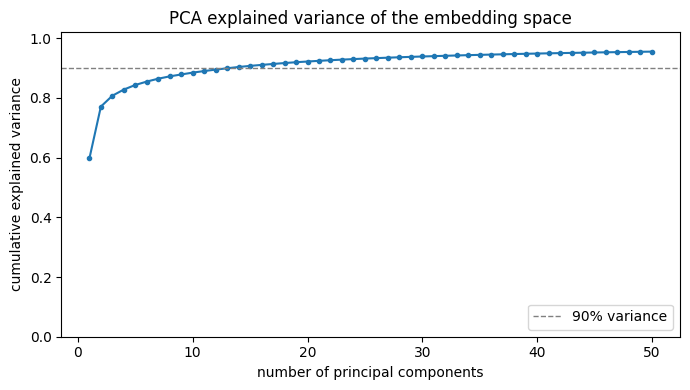

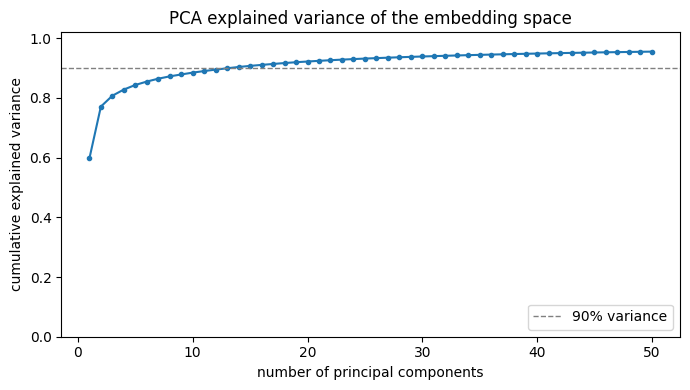

In [17]:
from http2vec.visualization.plots import plot_pca_explained_variance

fig = plot_pca_explained_variance(X, seed=config.seed)
show(fig, "3_3_pca_explained_variance")

## 4. Model training

We train the paper's supervised classifiers with **stratified k-fold
cross-validation** - Logistic Regression, Random Forest and linear SVC (the
paper's three) plus **Gradient Boosting** and **KNN** - and two unsupervised
detectors fitted on normal embeddings only: **Isolation Forest** (the paper's
spirit) and **Local Outlier Factor**. Section 4.1 adds a small trainable **MLP
head** (an extension beyond the paper). Every model exposes the same interface:
per request a continuous anomaly score and a hard class.

In [18]:
supervised_cv, supervised_holdout = pipeline.evaluate_supervised(embeddings)
anomaly = pipeline.evaluate_anomaly(embeddings)

rows = []
metric_keys = ["f1", "fbeta", "mcc", "roc_auc", "precision", "recall", "accuracy", "fpr_at_90", "fpr_at_99"]
for name, report in supervised_cv.items():
    row = {"model": name}
    row.update({k: report.cv[k]["mean"] for k in metric_keys if k in report.cv})
    rows.append(row)
cv_comparison = pd.DataFrame(rows).set_index("model")
print("Supervised classifiers - stratified 5-fold cross-validated means (paper protocol):")
cv_comparison.round(3)

Supervised classifiers - stratified 5-fold cross-validated means (paper protocol):


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.916,0.914,0.858,0.983,0.919,0.913,0.931,0.048,0.227
random_forest,0.833,0.840,0.714,0.950,0.822,0.844,0.861,0.169,0.333
linear_svc,0.909,0.908,0.845,0.979,0.910,0.907,0.925,0.058,0.299
gradient_boosting,0.860,0.859,0.762,0.964,0.861,0.859,0.885,0.131,0.277
knn,0.801,0.766,0.686,0.946,0.868,0.745,0.849,0.199,0.358


### 4.1 Trainable MLP head (extension beyond the paper)

Beyond the paper's frozen-embedding + classic-classifier recipe, we train a small
**MLP head** directly on the (still frozen) RoBERTa embeddings. Unlike the
language model - which sees only normal traffic - this head is *supervised*: it
uses labels, like the other classifiers. It is cheap, so we run it for several
epochs and capture a detailed train/validation learning curve. This is a
"fine-tune-like" addition: the RoBERTa weights themselves are not updated, only a
classifier on top of the embeddings. It is scored on the same shared holdout as
every other model, so it joins the unified comparison below on equal footing.

[INFO] http2vec: Trained MLP head: 19 epoch(s) run, best val_loss=0.1792 (restored).


MLP head (shared holdout): {'accuracy': 0.911, 'precision': 0.893, 'recall': 0.89, 'f1': 0.891, 'fbeta': 0.89, 'mcc': 0.816, 'roc_auc': 0.979, 'fpr_at_90': 0.08, 'fpr_at_99': 0.219}


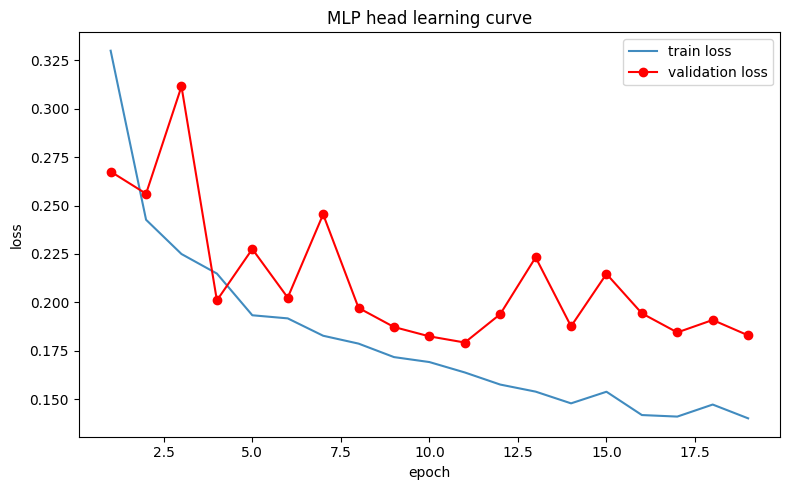

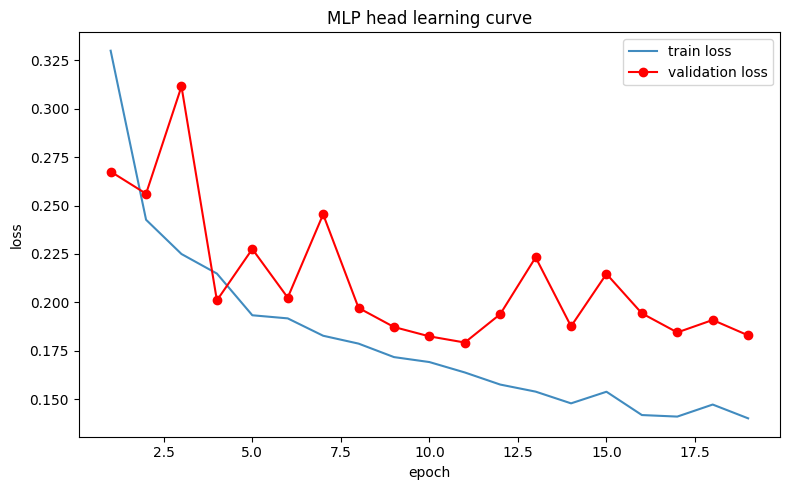

In [19]:
mlp_report, mlp_history = pipeline.evaluate_mlp_head(embeddings)
print("MLP head (shared holdout):",
      {k: round(v, 3) for k, v in mlp_report.metrics.items() if isinstance(v, float)})

fig = plot_training_curve(mlp_history, title="MLP head learning curve", show_perplexity=False)
show(fig, "4_1_mlp_learning_curve")

### 4.2 Unified model comparison (shared holdout)

The cross-validation above follows the paper for the supervised models, but to
compare *every* model - supervised, unsupervised and the MLP head - on an equal
footing we use **one shared, seeded stratified holdout split**: each supervised
model and the MLP head are trained on the same train split and scored on the same
test split, while the unsupervised detectors are fit on normal-only embeddings
and scored on that same test set. All the views below are built from a single
registry of per-model reports, so adding a model makes it appear everywhere.

In [ ]:
from http2vec.pipeline import comparison_frame
from http2vec.visualization.plots import plot_model_comparison

# One registry: name -> ClassificationReport, all on the SAME holdout test set.
model_reports = {}
model_reports.update(pipeline.evaluate_supervised_holdouts(embeddings))
model_reports.update(pipeline.evaluate_anomaly_detectors(embeddings))
model_reports["mlp_head (fine-tune)"] = mlp_report  # trained in Section 4.1

baseline_reports = {}
baseline_reports.update(pipeline.evaluate_descriptive_baseline(bundle, embeddings))
baseline_reports.update(pipeline.evaluate_lexical_baseline(bundle, embeddings))
model_reports.update(baseline_reports)

comparison_all = comparison_frame(model_reports)
print("Unified comparison on the shared holdout test set (incl. baselines):")
comparison_all.round(3)

Unified comparison on the shared holdout test set (incl. baselines):


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.913,0.910,0.853,0.984,0.918,0.909,0.929,0.050,0.210
random_forest,0.836,0.841,0.720,0.950,0.827,0.844,0.864,0.162,0.345
linear_svc,0.910,0.908,0.847,0.980,0.913,0.907,0.926,0.056,0.282
gradient_boosting,0.862,0.857,0.767,0.964,0.870,0.854,0.888,0.127,0.304
knn,0.798,0.759,0.683,0.945,0.873,0.735,0.847,0.194,0.344
isolation_forest,0.473,0.414,0.250,0.750,0.622,0.382,0.651,0.477,0.768
local_outlier_factor,0.336,0.240,0.360,0.837,1.000,0.202,0.672,0.649,0.953
mlp_head (fine-tune),0.891,0.890,0.816,0.979,0.893,0.890,0.911,0.080,0.219
handcrafted_lr,0.765,0.730,0.628,0.869,0.832,0.708,0.821,0.341,0.896


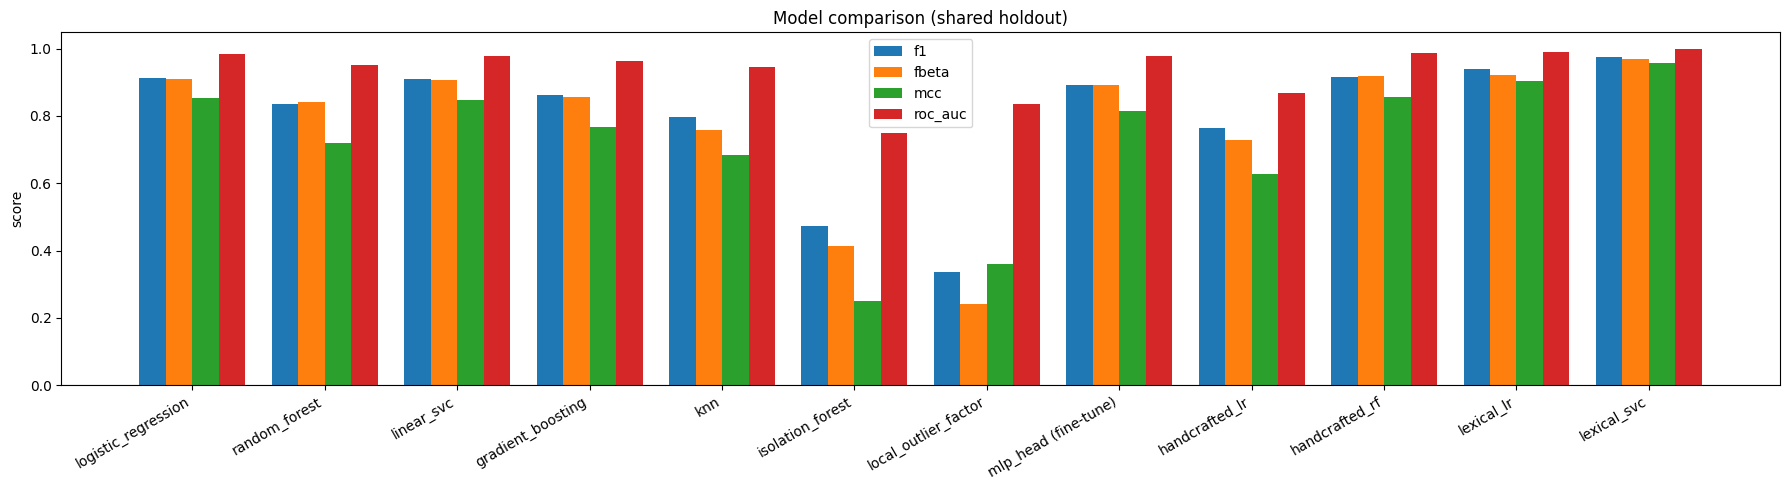

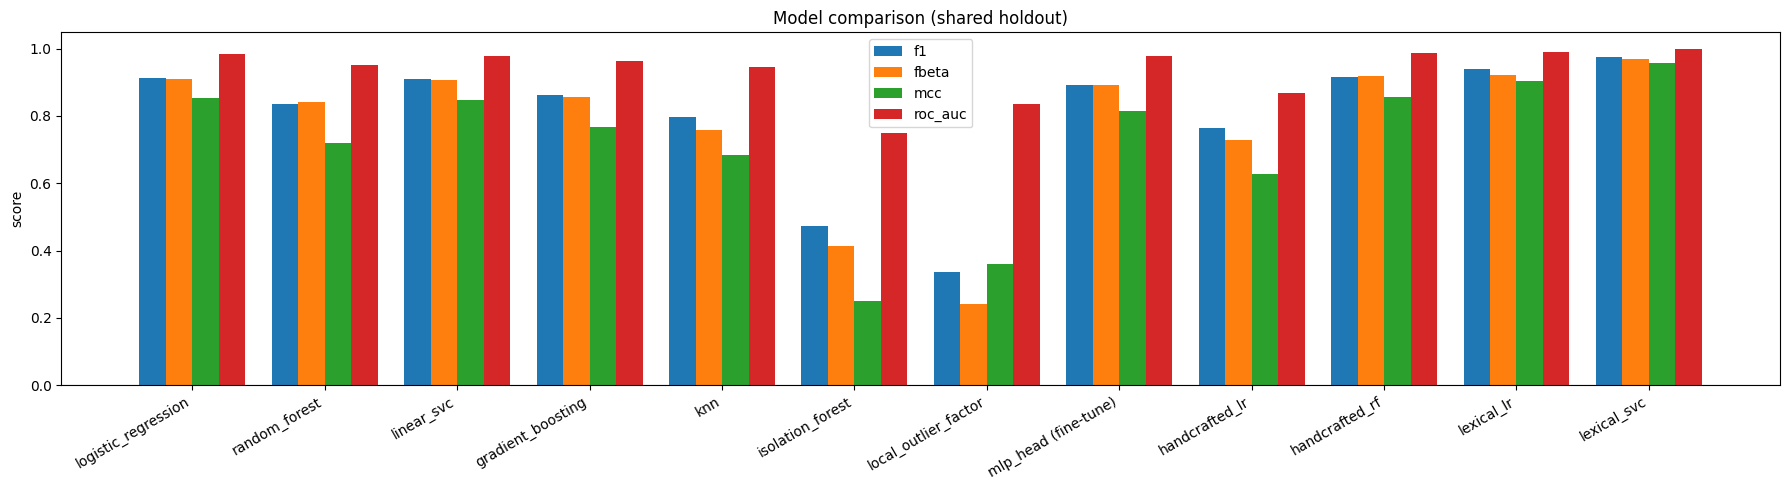

In [21]:
fig = plot_model_comparison(comparison_all, metrics=["f1", "fbeta", "mcc", "roc_auc"])
show(fig, "4_2_model_comparison_bars")

### 4.3 What does the embedding add over classic baselines?

The paper's thesis is that the *learned* representation is what matters. To test
that directly we compare the best embedding classifier against two non-embedding
baselines scored on the same holdout: a **handcrafted** baseline (classic models
on the descriptive features of Section 2) and a **lexical** baseline (character
n-gram TF-IDF on the raw request text - the simple bag-of-n-grams alternative the
paper's introduction contrasts itself with). The focused table and chart below
isolate that comparison; a small gap would mean the embedding buys little over
cheap features on CSIC, a large gap would justify the RoBERTa machinery.

Best embedding model (logistic_regression) vs non-embedding baselines:
                        f1  fbeta    mcc  roc_auc  precision  recall  \
model                                                                  
logistic_regression  0.913  0.910  0.853    0.984      0.918   0.909   
handcrafted_lr       0.765  0.730  0.628    0.869      0.832   0.708   
handcrafted_rf       0.915  0.919  0.856    0.988      0.909   0.921   
lexical_lr           0.941  0.922  0.903    0.991      0.973   0.910   
lexical_svc          0.975  0.969  0.958    0.998      0.984   0.966   

                     accuracy  fpr_at_90  fpr_at_99  
model                                                
logistic_regression     0.929      0.050      0.210  
handcrafted_lr          0.821      0.341      0.896  
handcrafted_rf          0.930      0.053      0.125  
lexical_lr              0.953      0.014      0.206  
lexical_svc             0.980      0.001      0.034  


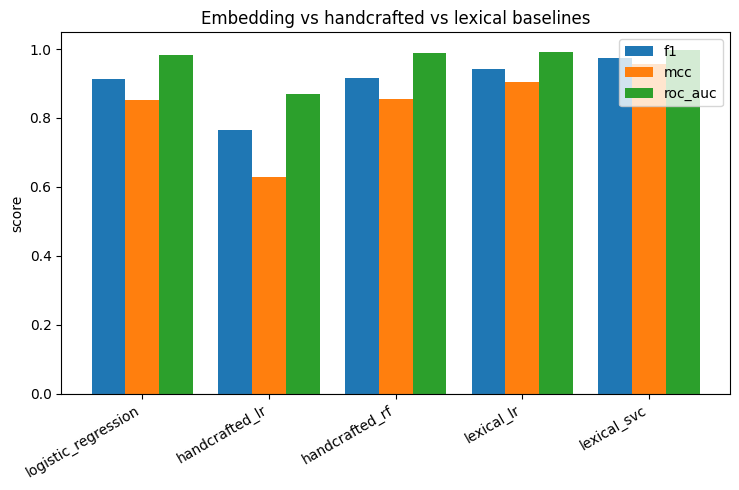

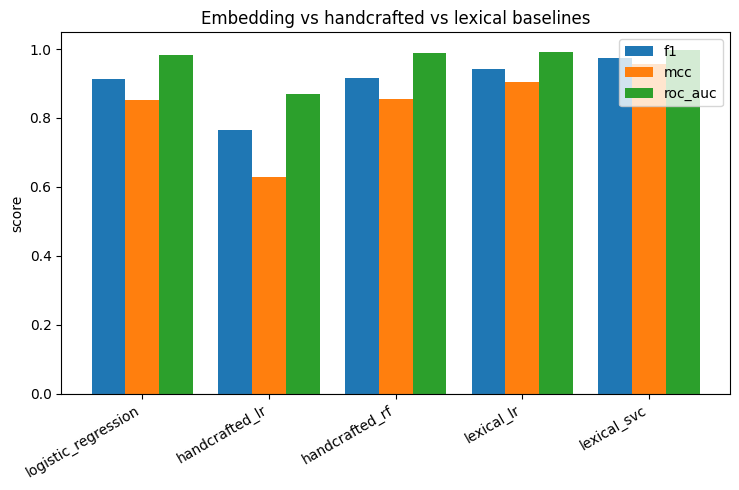

In [22]:
best_embed = supervised_holdout.name  # best embedding classifier (by CV F1)
focus_models = [best_embed] + list(baseline_reports)
baseline_focus = comparison_all.loc[[m for m in focus_models if m in comparison_all.index]]
baseline_focus.round(4).to_csv(REPORTS_DIR / "baseline_comparison.csv")
print(f"Best embedding model ({best_embed}) vs non-embedding baselines:")
print(baseline_focus.round(3))

fig = plot_model_comparison(
    baseline_focus,
    metrics=["f1", "mcc", "roc_auc"],
    title="Embedding vs handcrafted vs lexical baselines",
)
show(fig, "4_3_baseline_comparison")

### 4.4 How much do duplicate requests inflate the results?

Section 2.4 showed the real duplication lives at the **request-line** (template)
level, not the raw text. Two consequences are quantified here, both keyed on the
request line:

1. **Train/test leakage** - how many held-out test requests reuse a request-line
   template that also appears in the train split. Such a request is close to
   "already seen", so any score on it is optimistic.
2. **De-duplicated re-evaluation** - the best embedding classifier refit after
   keep-first de-duplication by request line (one representative per template), so
   no template spans the train/test split. The delta between the full-data and
   de-duplicated metrics is a direct measure of how much CSIC's templating
   flatters the headline numbers (expect F1/MCC to drop and FPR99 to rise).

The two holdouts differ in size (the de-duplicated set is much smaller), and
keep-first assigns a shared request line to its first occurrence; both are noted
so the comparison is read as "harder, more honest test", not a like-for-like one.

In [ ]:
from http2vec.data.duplicates import train_test_leakage

train_idx, test_idx = pipeline.shared_holdout_indices(embeddings)
leakage = train_test_leakage(first_lines, train_idx, test_idx)   
duplicate_analysis["train_test_leakage_first_line"] = leakage
print(f"Holdout-test requests sharing a request line with the train split: "
      f"{leakage['n_leaked']} / {leakage['n_test']} ({leakage['leakage_rate']:.1%})")


lm_set = set(bundle.lm_train.texts())
n_if_leak = sum(text in lm_set for text in raw_texts)
duplicate_analysis["lm_train_to_inference_exact"] = {"n_leaked": n_if_leak, "n_total": len(raw_texts)}
print(f"Inference requests that exactly duplicate an LM-training request: "
      f"{n_if_leak} / {len(raw_texts)}  (0 => no cross-file leakage into the detectors)")

# Refit the best embedding classifier on a request-line de-duplicated split and compare.
dedup_report = pipeline.evaluate_dedup_best(bundle, embeddings, model_name=best_embed, keys=first_lines)
delta_keys = ["f1", "mcc", "fpr_at_99"]
full_metrics = model_reports[best_embed].metrics
dedup_delta = pd.DataFrame({
    "full_data": {k: full_metrics.get(k) for k in delta_keys},
    "deduplicated": {k: dedup_report.metrics.get(k) for k in delta_keys},
})
dedup_delta["delta"] = dedup_delta["deduplicated"] - dedup_delta["full_data"]
duplicate_analysis["dedup_reeval"] = {
    "model": best_embed,
    "dedup_key": "first_line",
    "full_data": {k: float(full_metrics.get(k)) for k in delta_keys},
    "deduplicated": {k: float(dedup_report.metrics.get(k)) for k in delta_keys},
}
print(f"\n{best_embed}: full-data vs request-line de-duplicated holdout")
dedup_delta.round(3)

Holdout-test requests sharing a request line with the train split: 5691 / 7328 (77.7%)
Inference requests that exactly duplicate an LM-training request: 0 / 24426  (0 => no cross-file leakage into the detectors)

logistic_regression: full-data vs request-line de-duplicated holdout


,full_data,deduplicated,delta
f1,0.913,0.883,-0.030
mcc,0.853,0.649,-0.204
fpr_at_99,0.210,0.796,0.586


## 5. Evaluation

### Metrics and why they matter in this domain

- **Precision** - of the requests we flag as attacks, how many really are. Low
  precision means many **false positives** (benign traffic blocked - operator
  fatigue).
- **Recall (TPR)** - of the real attacks, how many we catch. Low recall means
  **false negatives** (attacks slip through - the dangerous failure).
- **F1 / Fβ** - harmonic mean of precision and recall; we use **β=2** to weight
  recall higher, because missing an attack is usually costlier than a false alarm.
- **MCC** - balanced even under class imbalance; robust single-number summary.
- **ROC-AUC** - threshold-independent ranking quality of the anomaly score.
- **FPR@TPR (FPR90/FPR99)** - the paper's headline: how many false positives we
  must accept to catch 90% / 99% of attacks.

### 5.1 ROC comparison (all models, shared holdout)

Every model from the registry overlaid on one ROC plot, so their threshold-free
ranking quality is directly comparable on the same test set.

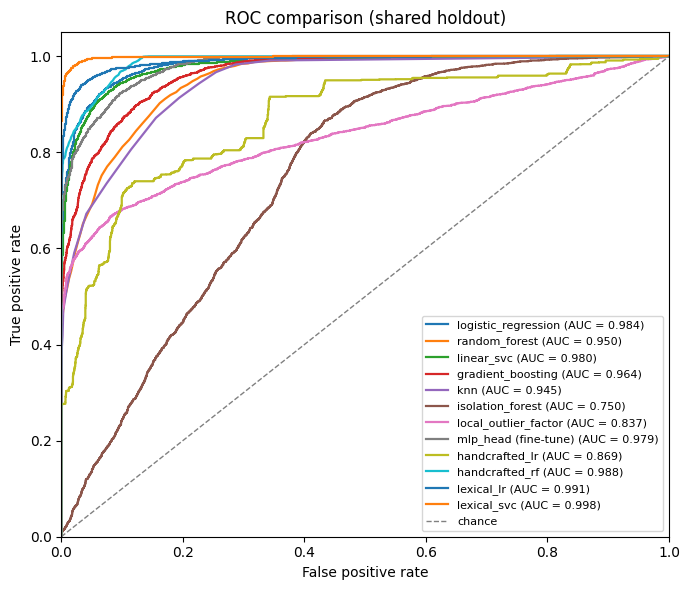

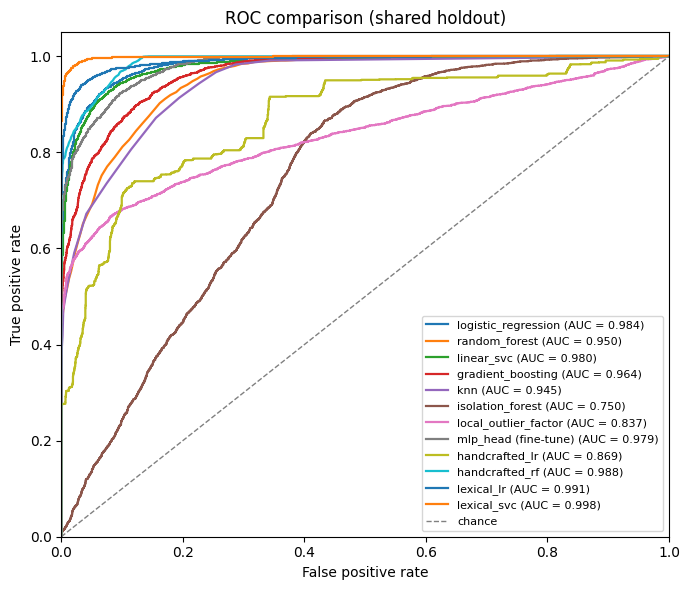

In [24]:
from http2vec.visualization.plots import plot_roc_comparison

roc_curves = {name: (report.y_true, report.y_score) for name, report in model_reports.items()}
fig = plot_roc_comparison(roc_curves)
show(fig, "5_1_roc_comparison")

### 5.2 Best supervised model (holdout)

A closer look at the single best supervised model: its confusion matrix and ROC.

Best supervised model on holdout: logistic_regression
{'accuracy': 0.929, 'precision': 0.918, 'recall': 0.909, 'f1': 0.913, 'fbeta': 0.91, 'mcc': 0.853, 'roc_auc': 0.984, 'fpr_at_90': 0.05, 'fpr_at_99': 0.21}


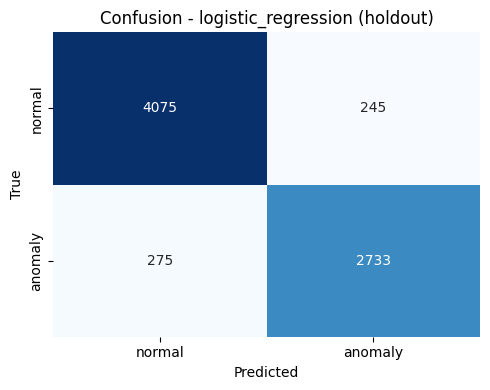

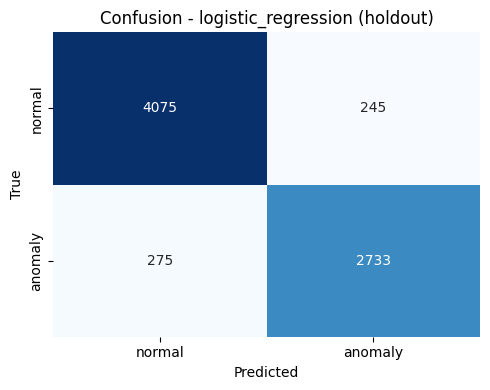

In [25]:
from http2vec.visualization.plots import plot_roc, plot_confusion_matrix, plot_score_distribution

print(f"Best supervised model on holdout: {supervised_holdout.name}")
print({k: round(v, 3) for k, v in supervised_holdout.metrics.items() if isinstance(v, float)})
fig = plot_confusion_matrix(supervised_holdout.y_true, supervised_holdout.y_pred,
                            title=f"Confusion - {supervised_holdout.name} (holdout)")
show(fig, "5_2_confusion_best_supervised")

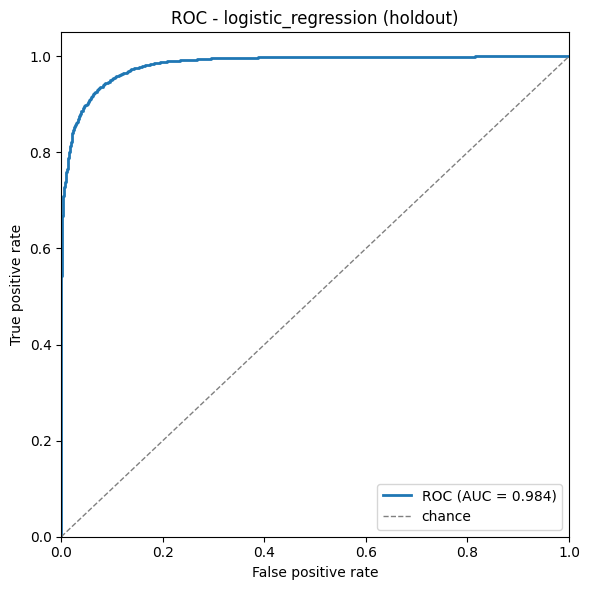

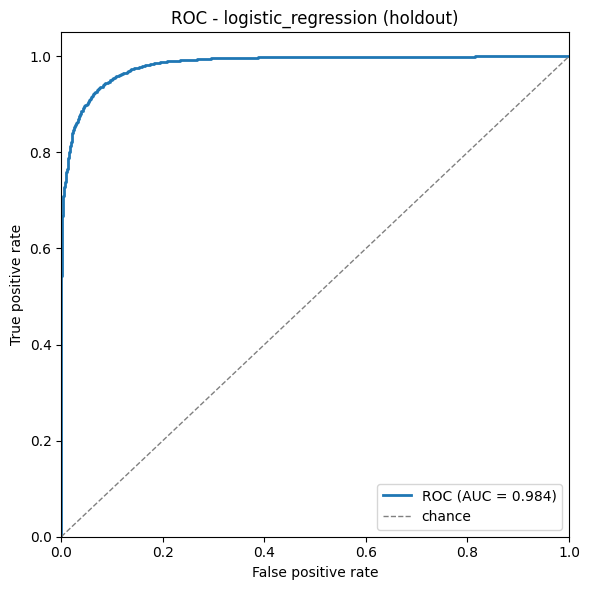

In [26]:
fig = plot_roc(supervised_holdout.y_true, supervised_holdout.y_score,
               title=f"ROC - {supervised_holdout.name} (holdout)")
show(fig, "5_2_roc_best_supervised")

### 5.3 Unsupervised detector (Isolation Forest)

Fitted on normal embeddings only, then asked to score the (mixed) inference set.
The two outputs per request are shown: the score distribution (degree of anomaly)
and the assigned class (confusion matrix).

Isolation Forest metrics (full inference set):
{'accuracy': 0.648, 'precision': 0.619, 'recall': 0.371, 'f1': 0.464, 'fbeta': 0.403, 'mcc': 0.242, 'roc_auc': 0.752, 'fpr_at_90': 0.477, 'fpr_at_99': 0.755}


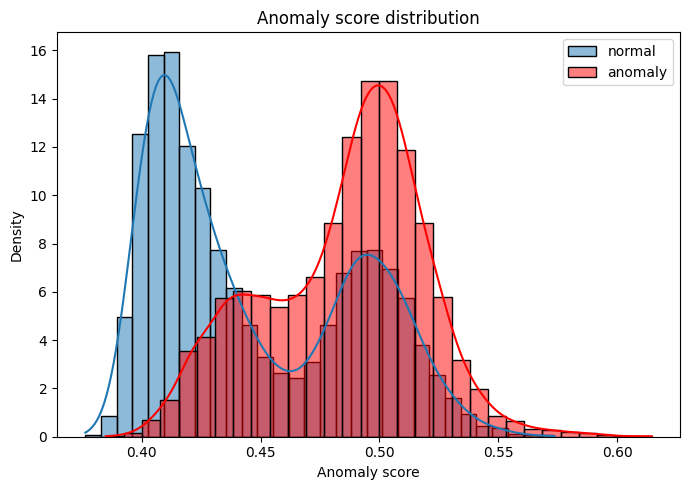

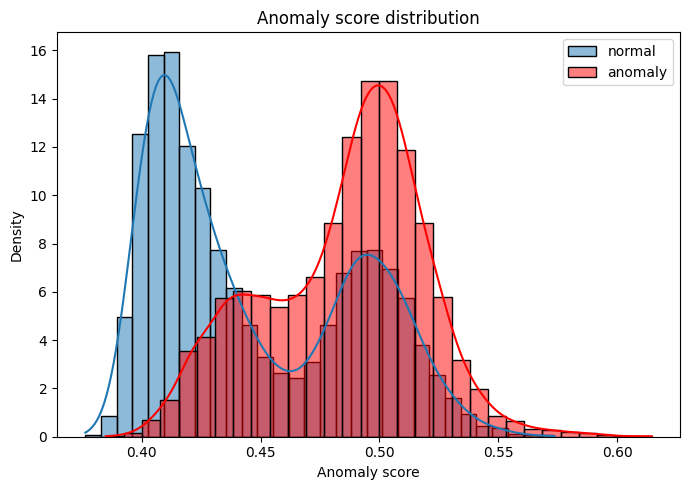

In [27]:
print("Isolation Forest metrics (full inference set):")
print({k: round(v, 3) for k, v in anomaly.metrics.items() if isinstance(v, float)})
fig = plot_score_distribution(anomaly.y_score, anomaly.y_true)
show(fig, "5_3_iforest_score_distribution")

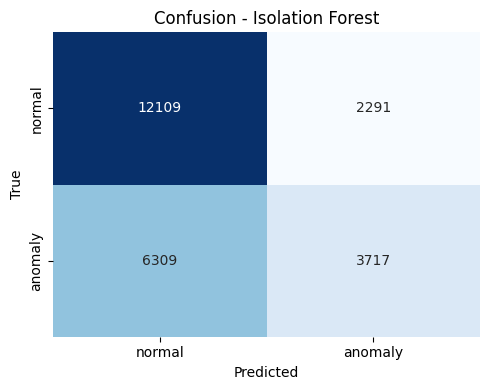

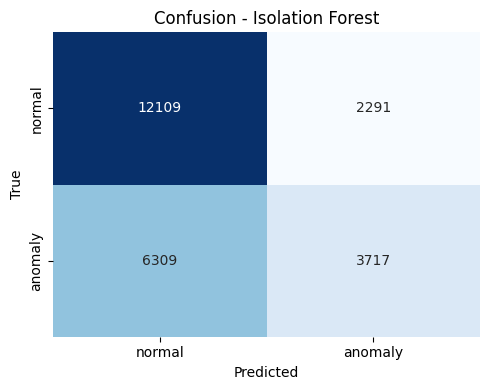

In [28]:
fig = plot_confusion_matrix(anomaly.y_true, anomaly.y_pred, title="Confusion - Isolation Forest")
show(fig, "5_3_confusion_iforest")

In [29]:
# Persist the unified comparison so the written report can cite exact numbers.
comparison_all.round(4).to_csv(REPORTS_DIR / "model_comparison.csv")
print("Saved reports/model_comparison.csv")
print("Figures saved under", FIG_DIR)

Saved reports/model_comparison.csv
Figures saved under reports/figures


## 6. Error analysis

We inspect false positives (benign flagged as attack) and false negatives
(attacks missed) from the Isolation Forest, which scores the full inference set in
order, so we can map errors straight back to the original requests.

In [30]:
inf_requests = bundle.inference.requests
y_true = anomaly.y_true
y_pred = anomaly.y_pred
fp_idx = np.where((y_pred == 1) & (y_true == 0))[0][:3]
fn_idx = np.where((y_pred == 0) & (y_true == 1))[0][:3]

print("False positives (benign flagged as attack):")
for i in fp_idx:
    print("  ", inf_requests[i].request_line[:160])
print("\nFalse negatives (attacks missed):")
for i in fn_idx:
    print("  ", inf_requests[i].request_line[:160])

print("\nFP count:", int(((y_pred == 1) & (y_true == 0)).sum()),
      "| FN count:", int(((y_pred == 0) & (y_true == 1)).sum()))

False positives (benign flagged as attack):
   GET http://localhost:8080/tienda1/publico/anadir.jsp?id=1&nombre=Jam%F3n+Ib%E9rico&precio=39&cantidad=41&B1=A%F1adir+al+carrito HTTP/1.1
   POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1
   POST http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1

False negatives (attacks missed):
   GET http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2FscrIPT%3E.parosproxy.org&pwd=84m3ri156&rememb
   GET http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=grimshaw&pwd=84m3ri156&rememberA=on&B1=Entrar HTTP/1.1
   GET http://localhost:8080/tienda1/publico/entrar.jsp?errorMsg=%2B HTTP/1.1

FP count: 2291 | FN count: 6309


### 6.1 Best supervised model: concrete false positives and false negatives

The Isolation Forest above is unsupervised. Here we do the same error analysis
for the **best supervised model** on the shared holdout, mapping each mistake back
to the original request via the shared test indices. These are the operationally
relevant errors (the model we would actually deploy), and the examples are saved
to `reports/error_examples.json` for the write-up.

In [31]:
from http2vec.pipeline import error_examples

sup_examples = error_examples(supervised_holdout, test_idx, bundle.inference.requests, k=3)
print(f"Best supervised model: {supervised_holdout.name}")
print(f"FP = {sup_examples['n_false_positives']}  |  FN = {sup_examples['n_false_negatives']}")
print("\nFalse positives (benign flagged as attack):")
for line in sup_examples["false_positives"]:
    print("  ", line[:160])
print("\nFalse negatives (attacks missed):")
for line in sup_examples["false_negatives"]:
    print("  ", line[:160])

# Collect both supervised and unsupervised examples for the report artifact.
error_examples_data = {
    f"supervised_{supervised_holdout.name}": sup_examples,
    "isolation_forest": {
        "n_false_positives": int(((y_pred == 1) & (y_true == 0)).sum()),
        "n_false_negatives": int(((y_pred == 0) & (y_true == 1)).sum()),
        "false_positives": [inf_requests[i].request_line for i in fp_idx],
        "false_negatives": [inf_requests[i].request_line for i in fn_idx],
    },
}

Best supervised model: logistic_regression
FP = 245  |  FN = 275

False positives (benign flagged as attack):
   POST http://localhost:8080/tienda1/miembros/editar.jsp HTTP/1.1
   POST http://localhost:8080/tienda1/miembros/editar.jsp HTTP/1.1
   POST http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1

False negatives (attacks missed):
   GET http://localhost:8080/tienda1/publico/registro.jsp?modo=registro&login=thi-cuc&password=PRof4rTo&nombre=Edberto&apellidos=Genov%E9s&email=keres_murriata%40o
   POST http://localhost:8080/tienda1/miembros/editar.jsp HTTP/1.1
   POST http://localhost:8080/tienda1/publico/autenticar.jsp HTTP/1.1


**False positive vs false negative trade-off.** In intrusion detection a false
negative (a missed attack) is typically far more costly than a false positive (a
false alarm). That is why we emphasise recall (Fβ with β=2) and report FPR at high
TPR: we want to catch almost all attacks while keeping the false-alarm rate
operationally acceptable. The decision threshold on the anomaly score is the knob
that trades one for the other.

## 7. Executive summary

The cell below assembles this run's headline numbers so the written report can
quote exact figures. It prints a compact recap and writes
`reports/results_summary.json`; the full per-model table is in
`reports/model_comparison.csv` and every figure is under `reports/figures/`.

In [32]:
import json, shutil

best_overall = comparison_all["f1"].idxmax()
summary = {
    "profile": PROFILE,
    "config": {
        "epochs": config.model.num_train_epochs,
        "subset_fraction": config.data.subset_fraction,
        "embedding_dim": int(embedder.embedding_dim),
    },
    "class_balance": {"normal": int((y == 0).sum()), "anomaly": int((y == 1).sum())},
    "best_supervised_holdout": supervised_holdout.name,
    "best_model_overall_by_f1": best_overall,
    "metrics_by_model": {
        name: {k: round(float(v), 4)
               for k, v in report.metrics.items()
               if isinstance(v, float) and v == v}
        for name, report in model_reports.items()
    },
    "duplicate_analysis": duplicate_analysis,
}
(REPORTS_DIR / "results_summary.json").write_text(json.dumps(summary, indent=2))
(REPORTS_DIR / "duplicate_analysis.json").write_text(json.dumps(duplicate_analysis, indent=2))
(REPORTS_DIR / "error_examples.json").write_text(json.dumps(error_examples_data, indent=2))

# Bundle everything the written report needs into a single downloadable archive.
bundle_path = shutil.make_archive("reports_bundle", "zip", root_dir=str(REPORTS_DIR))

print("Best model overall (by F1):", best_overall)
print("Saved under reports/:")
print("  - results_summary.json, duplicate_analysis.json, error_examples.json")
print("  - model_comparison.csv, baseline_comparison.csv")
print("  - figures/*.png")
print("Download this single bundle from Colab:", bundle_path)
comparison_all.round(3)

Best model overall (by F1): lexical_svc
Saved under reports/:
  - results_summary.json, duplicate_analysis.json, error_examples.json
  - model_comparison.csv, baseline_comparison.csv
  - figures/*.png
Download this single bundle from Colab: /content/cyberAno/reports_bundle.zip


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.913,0.910,0.853,0.984,0.918,0.909,0.929,0.050,0.210
random_forest,0.836,0.841,0.720,0.950,0.827,0.844,0.864,0.162,0.345
linear_svc,0.910,0.908,0.847,0.980,0.913,0.907,0.926,0.056,0.282
gradient_boosting,0.862,0.857,0.767,0.964,0.870,0.854,0.888,0.127,0.304
knn,0.798,0.759,0.683,0.945,0.873,0.735,0.847,0.194,0.344
isolation_forest,0.473,0.414,0.250,0.750,0.622,0.382,0.651,0.477,0.768
local_outlier_factor,0.336,0.240,0.360,0.837,1.000,0.202,0.672,0.649,0.953
mlp_head (fine-tune),0.891,0.890,0.816,0.979,0.893,0.890,0.911,0.080,0.219
handcrafted_lr,0.765,0.730,0.628,0.869,0.832,0.708,0.821,0.341,0.896


**Recap.**

- **Problem:** detect anomalous/attack HTTP requests on CSIC 2010.
- **Method:** RoBERTa embeddings of requests (LM trained on normal traffic only)
  plus supervised classifiers, two unsupervised detectors (Isolation Forest, LOF),
  a trainable MLP head over the frozen embeddings, and two non-embedding baselines
  (handcrafted descriptive features, char n-gram TF-IDF) for context.
- **Findings:** the embedding space separates classes (t-SNE), supervised models
  reach strong F1/MCC, the MLP head adds a learnable comparison point, the
  baselines quantify what the embedding actually adds, and duplicate/leakage
  analysis shows how much CSIC's templating inflates the headline numbers.
- **Caveats:** the numbers reflect the selected profile (default `small`: the
  full-size model on a 40% subset, 5 epochs); use `paper` for the full run.
